<a href="https://colab.research.google.com/github/cu24250216-oss/Computer-Vision-Experiments/blob/main/TANISHASINGH_60_EXPERIMENT10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Experiment No. 10**

**Character, Digit, or Face Classification using Convolutional Neural Network**s **(CNNs)**

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)

(60000, 28, 28, 1)


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.9518 - loss: 0.1607 - val_accuracy: 0.9827 - val_loss: 0.0586
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9842 - loss: 0.0502 - val_accuracy: 0.9872 - val_loss: 0.0400
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 0.9897 - loss: 0.0332 - val_accuracy: 0.9862 - val_loss: 0.0432
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9920 - loss: 0.0252 - val_accuracy: 0.9908 - val_loss: 0.0306
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9940 - loss: 0.0188 - val_accuracy: 0.9910 - val_loss: 0.0352


In [7]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9902 - loss: 0.0338
Test Loss: 0.03384403511881828
Test Accuracy: 0.9901999831199646


In [8]:
pred = model.predict(x_test)
y_pred = np.argmax(pred, axis=1)

print("Actual:", y_test[:10])
print("Predicted:", y_pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Actual: [7 2 1 0 4 1 4 9 5 9]
Predicted: [7 2 1 0 4 1 4 9 6 9]


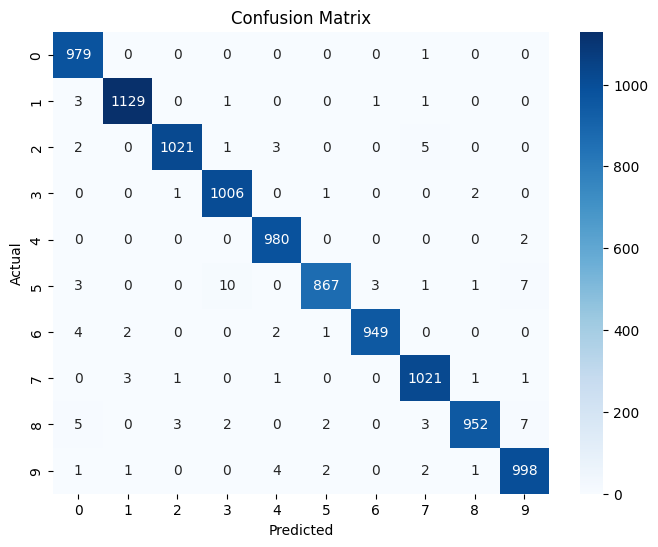

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

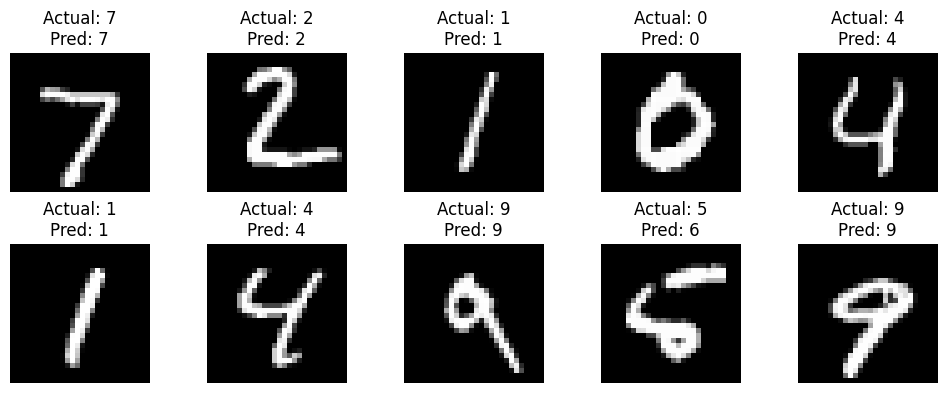

In [10]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Actual: {y_test[i]}\nPred: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

**Questions **

Q1. What is image classification? How does it differ from object detection and image segmentation?
Ans: Image classification assigns a label to an image. Object detection identifies objects and their locations. Segmentation labels each pixel.

Q2. Explain the architecture and working principle of CNN.
Ans: CNN uses Convolution → ReLU → Pooling → Flatten → Fully Connected → Softmax to extract features and classify images.

Q3. Role of Convolution, Pooling and Fully Connected layers?
Ans: Convolution extracts features, Pooling reduces dimensions, and Fully Connected layers classify the image.

Q4. Why is image normalization performed?
Ans: It converts pixel values from 0–255 to 0–1, making training faster and more stable.

Q5. Purpose of ReLU and Softmax?
Ans: ReLU adds non-linearity, while Softmax converts outputs into class probabilities.

Q6. What is a Confusion Matrix?
Ans: It is a table showing the actual and predicted classes of a classification model.

Q7. Differentiate Accuracy, Precision, Recall and F1-Score.
Ans:

Accuracy: Overall correct predictions.
Precision: Correct positive predictions.
Recall: Correctly identified positive samples.
F1-score: Balance of precision and recall.

Q8. SIFT/HOG + SVM vs CNN?
Ans: SIFT/HOG uses manually extracted features with SVM, while CNN automatically learns features and performs classification.

Q9. Five applications of CNN.
Ans: Face recognition, medical imaging, handwritten digit recognition, traffic sign recognition, and product classification.

Q10. How do Data Augmentation, Transfer Learning and Hyperparameter Tuning help?
Ans: Data augmentation increases training data, transfer learning uses a pretrained model, and hyperparameter tuning improves model performance.